# 📷 CP Plus DVR — Stream Discovery & YOLOv8 Person Detection

**DVR Details extracted from your device:**
- IP: `192.168.0.4` | RTSP Port: `554`
- RTSP Format: `rtsp://apex:admin@26@192.168.0.4:554/cam/realmonitor?channel=N&subtype=0`
- Channels: 1–16 | subtype `0` = Main Stream, `1` = Sub Stream
- Model: **YOLOv8** | Task: **Person Detection**

---
### Notebook flow:
1. Install dependencies
2. Configure DVR credentials
3. Discover active channels
4. Preview frames from each live channel
5. Run YOLOv8 person detection on one or all channels
6. Multi-channel live inference with display

## 1️⃣ Install Dependencies

In [1]:
# Run once — installs everything needed
!pip install ultralytics opencv-python-headless Pillow requests tqdm -q


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2️⃣ DVR Configuration

In [4]:
# ─────────────────────────────────────────────
#  DVR SETTINGS  — edit only this cell
# ─────────────────────────────────────────────

# DVR_IP       =    # IP from your device
# RTSP_PORT    =              # RTSP port
# USERNAME     =           # DVR username
# PASSWORD     =       # DVR password
TOTAL_CH     =  12            # Max channels on your DVR
SUBTYPE      =  1             # 0 = Main (HD), 1 = Sub (lower res, faster ML)
DVR_IP       = "192.168.0.4"   # IP from your device
RTSP_PORT    = 554             # RTSP port
USERNAME     = "apex"          # DVR username
PASSWORD     = "admin@26"      # DVR password

def rtsp_url(channel: int, subtype: int = SUBTYPE) -> str:
    """Build CP Plus / Dahua RTSP URL for a given channel."""
    return (
        f"rtsp://{USERNAME}:{PASSWORD}@{DVR_IP}:{RTSP_PORT}"
        f"/cam/realmonitor?channel={channel}&subtype={subtype}"
    )

print("Sample URL (channel 1):", rtsp_url(1))

Sample URL (channel 1): rtsp://apex:admin@26@192.168.0.4:554/cam/realmonitor?channel=1&subtype=1


## 3️⃣ Discover Active Channels
Probes all 16 channels and finds which ones have a live video feed.

In [5]:
import cv2
from tqdm.notebook import tqdm
import time

def probe_channel(channel: int, timeout: float = 5.0) -> bool:
    """Returns True if channel has a readable video stream."""
    url = rtsp_url(channel)
    cap = cv2.VideoCapture(url, cv2.CAP_FFMPEG)
    cap.set(cv2.CAP_PROP_OPEN_TIMEOUT_MSEC, timeout * 1000)
    cap.set(cv2.CAP_PROP_READ_TIMEOUT_MSEC, timeout * 1000)
    ok, frame = cap.read()
    cap.release()
    return ok and frame is not None

print("🔍 Scanning channels 1 –", TOTAL_CH, "...")
active_channels = []

for ch in tqdm(range(1, TOTAL_CH + 1), desc="Probing"):
    alive = probe_channel(ch)
    status = "✅ LIVE" if alive else "❌ no signal"
    print(f"  Channel {ch:02d}: {status}")
    if alive:
        active_channels.append(ch)

print(f"\n📡 Active channels: {active_channels}")

🔍 Scanning channels 1 – 12 ...


Probing:   0%|          | 0/12 [00:00<?, ?it/s]

  Channel 01: ✅ LIVE
  Channel 02: ✅ LIVE
  Channel 03: ✅ LIVE
  Channel 04: ✅ LIVE
  Channel 05: ✅ LIVE
  Channel 06: ✅ LIVE
  Channel 07: ✅ LIVE
  Channel 08: ✅ LIVE
  Channel 09: ✅ LIVE
  Channel 10: ✅ LIVE
  Channel 11: ✅ LIVE
  Channel 12: ✅ LIVE

📡 Active channels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## 4️⃣ Preview One Frame from Each Active Channel

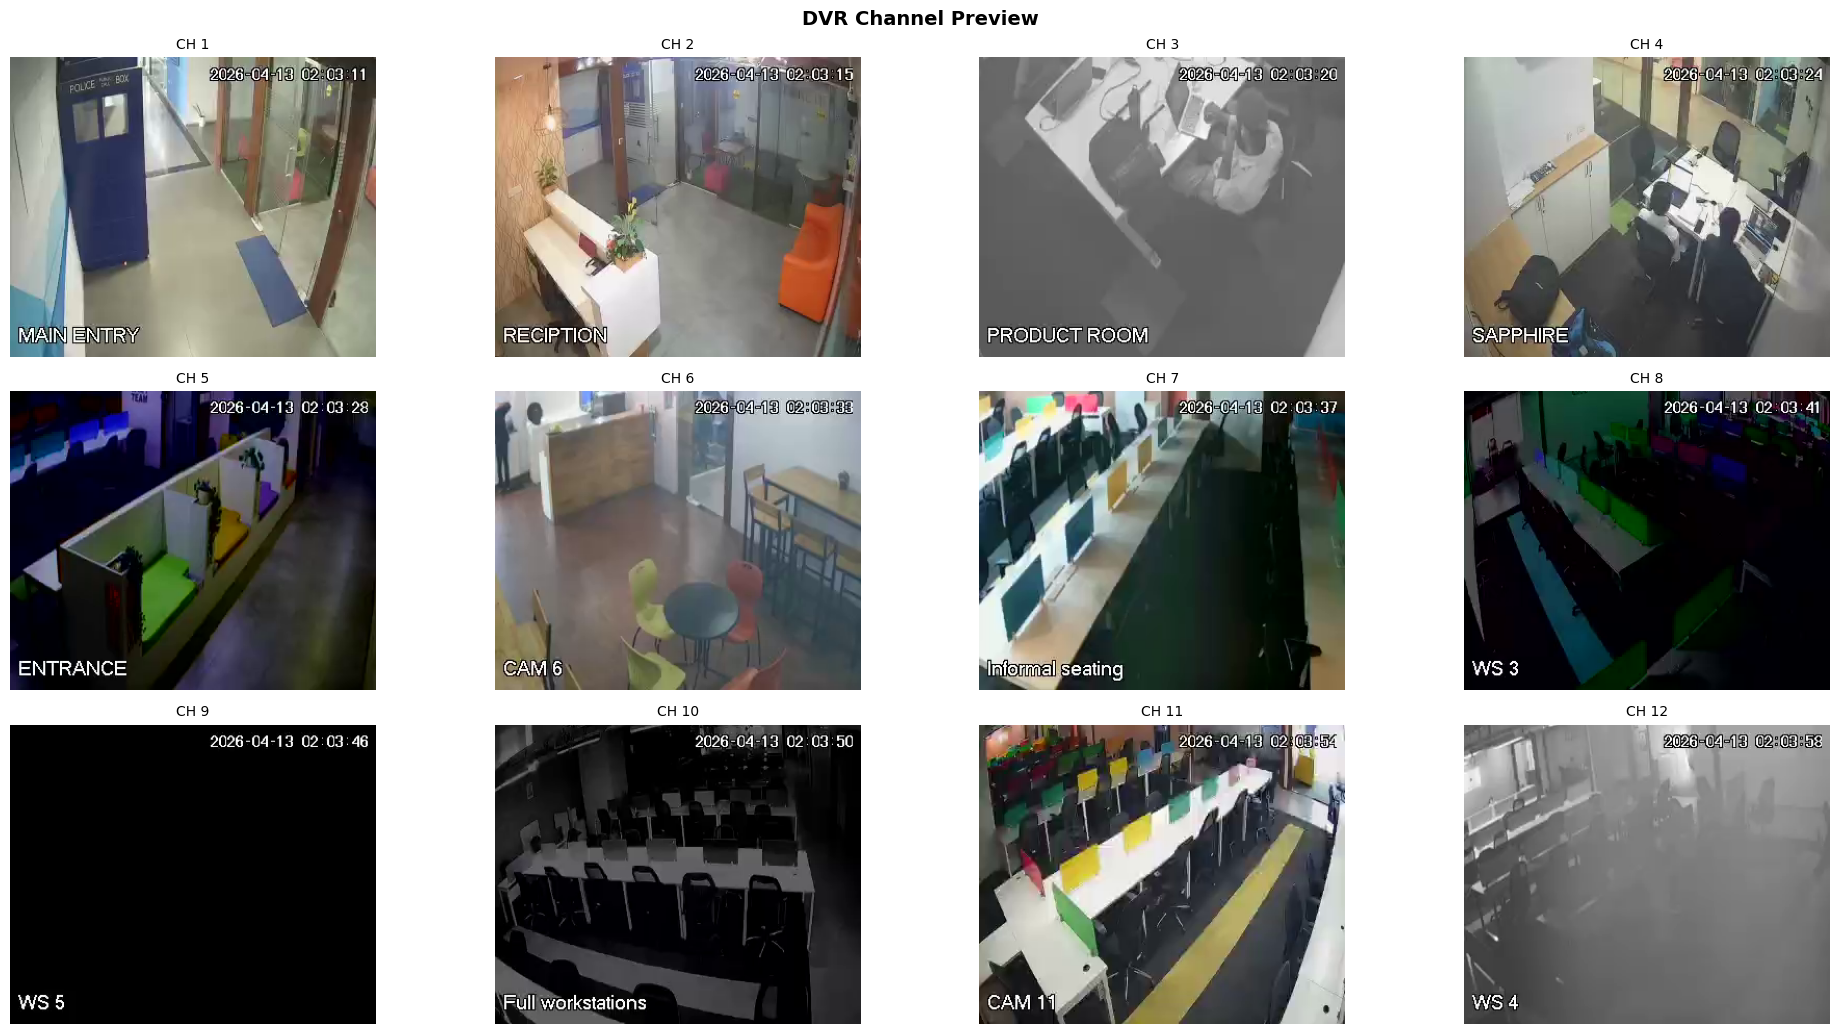

✅ Saved → channel_preview.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def grab_frame(channel: int) -> np.ndarray | None:
    """Grab a single frame from a channel."""
    cap = cv2.VideoCapture(rtsp_url(channel), cv2.CAP_FFMPEG)
    cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
    ok, frame = cap.read()
    cap.release()
    if ok:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None

if not active_channels:
    print("⚠️  No active channels found. Check network/credentials.")
else:
    cols = min(4, len(active_channels))
    rows = (len(active_channels) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5))
    axes = np.array(axes).flatten()

    for i, ch in enumerate(active_channels):
        frame = grab_frame(ch)
        if frame is not None:
            axes[i].imshow(frame)
            axes[i].set_title(f"CH {ch}", fontsize=10)
        else:
            axes[i].set_title(f"CH {ch} — failed", color="red")
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("DVR Channel Preview", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("channel_preview.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Saved → channel_preview.png")

## 5️⃣ Load YOLOv8 Model

In [5]:
from ultralytics import YOLO

# yolov8n = nano (fastest), yolov8s = small, yolov8m = medium
MODEL_SIZE = "yolov8n"   # change to yolov8s or yolov8m for better accuracy

model = YOLO(f"{MODEL_SIZE}.pt")   # downloads ~6 MB on first run
print(f"✅ Loaded {MODEL_SIZE} — classes: {len(model.names)}")

# Person class ID in COCO is 0
PERSON_CLASS_ID = 0
CONFIDENCE_THRESHOLD = 0.45   # tweak: lower = more detections, higher = fewer false positives

print(f"   Detecting: class {PERSON_CLASS_ID} = '{model.names[PERSON_CLASS_ID]}'")

100%|██████████| 6.25M/6.25M [00:01<00:00, 3.76MB/s]


✅ Loaded yolov8n — classes: 80
   Detecting: class 0 = 'person'


## 6️⃣ Single-Channel YOLO Inference (Test Run)
Grab one frame from a channel and run person detection on it.

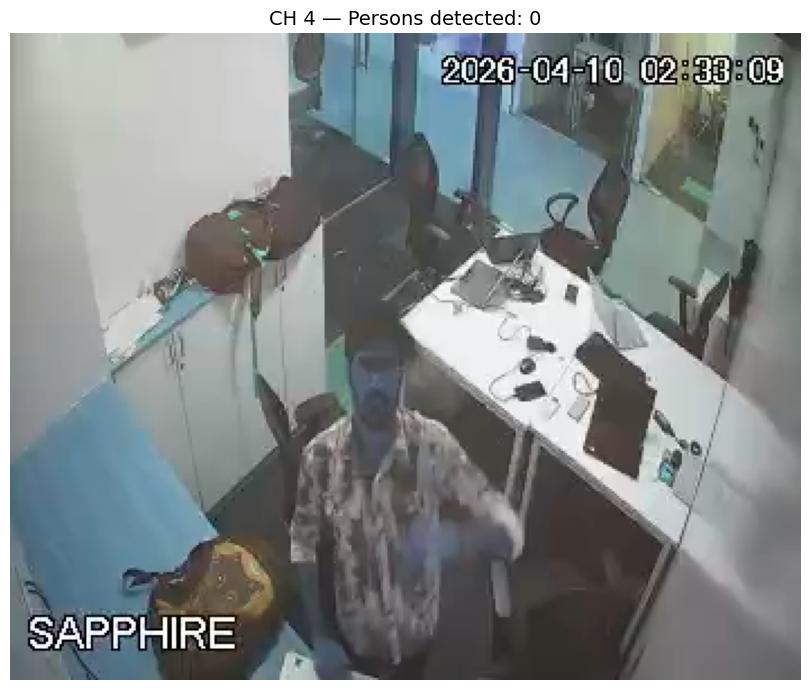

✅ Detected 0 person(s) on channel 4


In [12]:
TEST_CHANNEL = active_channels[3] if active_channels else 1  # change to any channel number

frame = grab_frame(TEST_CHANNEL)

if frame is None:
    print(f"⚠️  Could not grab frame from channel {TEST_CHANNEL}")
else:
    # Run inference — only detect persons (class 0)
    results = model(
        frame,
        classes=[PERSON_CLASS_ID],
        conf=CONFIDENCE_THRESHOLD,
        verbose=False
    )[0]

    annotated = results.plot()  # draws bboxes on frame
    person_count = int((results.boxes.cls == PERSON_CLASS_ID).sum())

    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"CH {TEST_CHANNEL} — Persons detected: {person_count}", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"yolo_ch{TEST_CHANNEL}_test.png", dpi=120)
    plt.show()
    print(f"✅ Detected {person_count} person(s) on channel {TEST_CHANNEL}")

## 7️⃣ Live RTSP Inference — Single Channel
Runs YOLOv8 continuously on a single channel stream. Press **`q`** in the OpenCV window to stop (or interrupt the kernel).

In [13]:
# ── Configuration ──────────────────────────────────────────────
LIVE_CHANNEL   = active_channels[3] if active_channels else 1
FRAME_SKIP     = 2      # process every Nth frame (1 = every frame)
SAVE_VIDEO     = True   # save annotated output to file
OUTPUT_FILE    = f"output_ch{LIVE_CHANNEL}.mp4"
# ───────────────────────────────────────────────────────────────

import time

cap = cv2.VideoCapture(rtsp_url(LIVE_CHANNEL), cv2.CAP_FFMPEG)
cap.set(cv2.CAP_PROP_BUFFERSIZE, 2)

if not cap.isOpened():
    print(f"❌ Could not open channel {LIVE_CHANNEL}")
else:
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 15
    print(f"📺 Channel {LIVE_CHANNEL}: {w}x{h} @ {fps:.1f} fps")

    writer = None
    if SAVE_VIDEO:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(OUTPUT_FILE, fourcc, fps / FRAME_SKIP, (w, h))
        print(f"🎥 Saving to {OUTPUT_FILE}")

    frame_idx = 0
    t0 = time.time()
    try:
        while True:
            ok, bgr = cap.read()
            if not ok:
                print("⚠️  Frame read failed — reconnecting...")
                cap.release()
                time.sleep(1)
                cap = cv2.VideoCapture(rtsp_url(LIVE_CHANNEL), cv2.CAP_FFMPEG)
                continue

            frame_idx += 1
            if frame_idx % FRAME_SKIP != 0:
                continue

            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            results = model(
                rgb,
                classes=[PERSON_CLASS_ID],
                conf=CONFIDENCE_THRESHOLD,
                verbose=False
            )[0]

            annotated_bgr = results.plot()  # BGR for cv2
            persons = int((results.boxes.cls == PERSON_CLASS_ID).sum())

            # Overlay info
            elapsed = time.time() - t0
            inf_ms  = results.speed.get("inference", 0)
            label   = f"CH{LIVE_CHANNEL} | Persons: {persons} | {inf_ms:.0f}ms/frame"
            cv2.rectangle(annotated_bgr, (0, 0), (len(label) * 10 + 10, 30), (0, 0, 0), -1)
            cv2.putText(annotated_bgr, label, (5, 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

            if writer:
                writer.write(annotated_bgr)

            cv2.imshow(f"YOLOv8 — Channel {LIVE_CHANNEL}", annotated_bgr)
            if cv2.waitKey(1) & 0xFF == ord("q"):
                print("👋 Stopped by user.")
                break

    except KeyboardInterrupt:
        print("⛔ Interrupted.")
    finally:
        cap.release()
        if writer:
            writer.release()
        cv2.destroyAllWindows()
        print(f"✅ Done. Frames processed: {frame_idx // FRAME_SKIP}")

📺 Channel 4: 352x288 @ 7.0 fps
🎥 Saving to output_ch4.mp4
👋 Stopped by user.
✅ Done. Frames processed: 404


## 8️⃣ Multi-Channel Grid Inference (Snapshot)
Runs YOLO on all active channels simultaneously and shows a combined grid — great for monitoring dashboards.

In [ ]:
import threading

def infer_channel(ch, results_dict):
    """Thread worker: grabs one frame, runs YOLO, stores annotated result."""
    frame = grab_frame(ch)
    if frame is None:
        results_dict[ch] = None
        return
    res = model(
        frame,
        classes=[PERSON_CLASS_ID],
        conf=CONFIDENCE_THRESHOLD,
        verbose=False
    )[0]
    annotated = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    persons = int((res.boxes.cls == PERSON_CLASS_ID).sum())
    results_dict[ch] = {"frame": annotated, "persons": persons}

if not active_channels:
    print("⚠️  No active channels.")
else:
    results_dict = {}
    threads = [threading.Thread(target=infer_channel, args=(ch, results_dict))
               for ch in active_channels]
    print(f"🚀 Running parallel YOLO on {len(active_channels)} channels...")
    for t in threads: t.start()
    for t in threads: t.join()

    cols = min(4, len(active_channels))
    rows = (len(active_channels) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.5))
    axes = np.array(axes).flatten()

    total_persons = 0
    for i, ch in enumerate(active_channels):
        r = results_dict.get(ch)
        if r and r["frame"] is not None:
            axes[i].imshow(r["frame"])
            axes[i].set_title(f"CH {ch} — 👤 {r['persons']} person(s)", fontsize=9)
            total_persons += r["persons"]
        else:
            axes[i].set_title(f"CH {ch} — ❌ no frame", color="red", fontsize=9)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"YOLOv8 Multi-Channel — Total Persons: {total_persons}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("yolo_multichannel_grid.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n👥 Total persons across all channels: {total_persons}")
    print("✅ Saved → yolo_multichannel_grid.png")

## 9️⃣ Person Count Logger (CSV)
Runs in a loop, logs person counts per channel to a CSV file with timestamps — useful for occupancy analytics.

In [ ]:
import csv
import datetime

LOG_FILE        = "person_count_log.csv"
LOG_INTERVAL_S  = 10    # snapshot every N seconds
LOG_DURATION_S  = 60    # total logging duration in seconds (set 0 for infinite)

fieldnames = ["timestamp"] + [f"ch_{ch}" for ch in active_channels] + ["total"]

def snapshot_all_channels():
    """Parallel snapshot of all active channels."""
    results_dict = {}
    threads = [threading.Thread(target=infer_channel, args=(ch, results_dict))
               for ch in active_channels]
    for t in threads: t.start()
    for t in threads: t.join()
    return results_dict

with open(LOG_FILE, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    start = time.time()
    iteration = 0
    print(f"📝 Logging to {LOG_FILE} every {LOG_INTERVAL_S}s ...")
    try:
        while True:
            rd = snapshot_all_channels()
            row = {"timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
            total = 0
            for ch in active_channels:
                count = rd[ch]["persons"] if rd.get(ch) else 0
                row[f"ch_{ch}"] = count
                total += count
            row["total"] = total
            writer.writerow(row)
            f.flush()
            iteration += 1
            print(f"  [{row['timestamp']}] Total persons: {total} | Row #{iteration}")

            elapsed = time.time() - start
            if LOG_DURATION_S and elapsed >= LOG_DURATION_S:
                break
            time.sleep(LOG_INTERVAL_S)
    except KeyboardInterrupt:
        print("⛔ Logging stopped.")

print(f"\n✅ Log saved → {LOG_FILE}")

## 🔟 Plot Person Count Over Time

In [ ]:
import pandas as pd

df = pd.read_csv(LOG_FILE, parse_dates=["timestamp"])
df.set_index("timestamp", inplace=True)

fig, ax = plt.subplots(figsize=(14, 5))
for ch in active_channels:
    col = f"ch_{ch}"
    if col in df.columns:
        ax.plot(df.index, df[col], marker="o", label=f"CH {ch}", linewidth=1.5)
ax.plot(df.index, df["total"], "k--", linewidth=2, label="Total", alpha=0.7)

ax.set_title("Person Count Over Time — All Channels", fontsize=13)
ax.set_xlabel("Time")
ax.set_ylabel("Persons detected")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("person_count_chart.png", dpi=120)
plt.show()
print("✅ Chart saved → person_count_chart.png")

---
## ℹ️ Troubleshooting

| Problem | Fix |
|---|---|
| `No active channels found` | Make sure your machine is on the **same subnet** as `192.168.0.x` |
| Stream opens but no frame | Try `subtype=0` (Main Stream) instead of 1 |
| Very slow inference | Use `yolov8n` (nano) + set `SUBTYPE=1` (sub-stream is lower res) |
| OpenCV window doesn't appear | In Jupyter, use cell 6 (snapshot) or cell 8 (grid) instead of live window |
| RTSP authentication error | Double-check username/password in cell 2 |